Prediction for alopecia-areata-21.jpg: Alopecia Areata


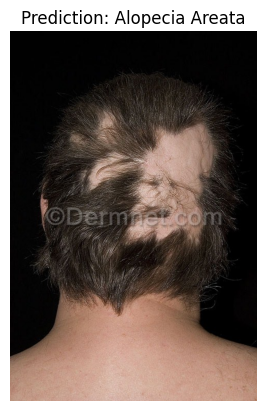

In [2]:
import os
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transforms
test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Path to your test image
image_path = r"D:\PROJECT\HAIR_LOSS_DL\Dataset\val\Alopecia Areata\alopecia-areata-21.jpg"

# Load and preprocess the image
image = Image.open(image_path).convert("RGB")
image_tensor = test_transforms(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

# Load the checkpoint dictionary
checkpoint = torch.load("best_model.pth", map_location=device)
model_name = checkpoint["model_name"]
state_dict = checkpoint["state_dict"]

# Define the number of classes (update as needed)
num_classes = 2

# Rebuild the model architecture based on the saved model name
if model_name == "ResNet50":
    model = models.resnet50(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
elif model_name == "DenseNet121":
    model = models.densenet121(pretrained=False)
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, num_classes)
elif model_name == "EfficientNetB0":
    model = models.efficientnet_b0(pretrained=False)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
else:
    raise ValueError("Unsupported model type!")

# Load the state dict and prepare the model for evaluation
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# Make prediction
with torch.no_grad():
    outputs = model(image_tensor)
    _, pred = torch.max(outputs, 1)

# Define class names (update according to your dataset)
class_names = ["Alopecia Areata", "Normal hairs"]
prediction = class_names[pred.item()]

print(f"Prediction for {os.path.basename(image_path)}: {prediction}")

# Display the image with prediction
plt.imshow(image)
plt.title(f"Prediction: {prediction}")
plt.axis('off')
plt.show()
